## The working training

In [1]:
# ============================================================
# Full training script: ShipEnv + Planner + PPO + Curriculum
# ============================================================

import os
from datetime import datetime
import numpy as np

# Gym / SB3
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList, BaseCallback


# ============================================================
# =============== GEOMETRY & PLANNER HELPERS =================
# ============================================================

def to_float_poly(poly):
    return np.array(poly, dtype=np.float32)

def polygon_area(poly):
    poly = to_float_poly(poly)
    s = 0.0
    for i in range(len(poly)):
        x1,y1 = poly[i]
        x2,y2 = poly[(i+1)%len(poly)]
        s += x1*y2 - x2*y1
    return s/2.0

def ensure_ccw(poly):
    poly = to_float_poly(poly)
    return poly if polygon_area(poly) > 0 else poly[::-1]

def point_to_segment_distance(p, a, b):
    p = np.asarray(p, dtype=np.float32)
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    ap = p - a
    ab = b - a
    denom = float(np.dot(ab,ab))
    if denom < 1e-12:
        return float(np.linalg.norm(p-a)), a
    t = float(np.dot(ap,ab)/denom)
    t = np.clip(t, 0.0, 1.0)
    cp = a + t*ab
    return float(np.linalg.norm(p-cp)), cp

def bbox_of(poly):
    poly = to_float_poly(poly)
    mn = np.min(poly, axis=0)
    mx = np.max(poly, axis=0)
    return mn, mx

def point_in_polygon_fast(p, poly, bbox=None):
    if bbox is not None:
        mn, mx = bbox
        if p[0] < mn[0] or p[0] > mx[0] or p[1] < mn[1] or p[1] > mx[1]:
            return False
    inside = False
    x, y = float(p[0]), float(p[1])
    n = len(poly)
    for i in range(n):
        x1,y1 = poly[i]
        x2,y2 = poly[(i+1)%n]
        if (y1 > y) != (y2 > y):
            X = (y - y1) * (x2 - x1) / ((y2 - y1) + 1e-12) + x1
            if x < X:
                inside = not inside
    return inside

def closest_point_on_polygon(p, poly):
    """
    Return (distance, closest_point, outward_dir_approx).
    outward_dir_approx is (p - cp) normalized; good to push out.
    """
    p = np.asarray(p, dtype=np.float32)
    best_d = 1e9
    best_cp = None
    best_dir = None
    n = len(poly)
    for i in range(n):
        a = poly[i]
        b = poly[(i+1)%n]
        d, cp = point_to_segment_distance(p, a, b)
        if d < best_d:
            best_d = d
            v = p - cp
            if np.linalg.norm(v) < 1e-9:
                e = b - a
                v = np.array([e[1], -e[0]], dtype=np.float32)
            best_dir = v / (np.linalg.norm(v) + 1e-12)
            best_cp  = cp
    return best_d, best_cp, best_dir

def outward_normals_ccw(poly_ccw):
    normals=[]
    n=len(poly_ccw)
    for i in range(n):
        p1=poly_ccw[i]; p2=poly_ccw[(i+1)%n]
        e = p2 - p1
        nvec = np.array([e[1], -e[0]], dtype=np.float32)
        nvec /= (np.linalg.norm(nvec) + 1e-12)
        normals.append(nvec)
    return normals

def offset_polygon(poly, clearance):
    poly_ccw = ensure_ccw(poly)
    normals = outward_normals_ccw(poly_ccw)
    out = [p + np.float32(clearance)*n for p,n in zip(poly_ccw, normals)]
    return np.array(out, dtype=np.float32)

def build_clearance_data(obstacles, clearance):
    circles = []
    polys   = []
    for obs in obstacles:
        if obs["type"] == "circle":
            c = np.array(obs["center"], dtype=np.float32)
            Rc = np.float32(obs["radius"] + clearance)
            circles.append((c, Rc))
        elif obs["type"] == "polygon":
            base = ensure_ccw(obs["points"])
            off  = offset_polygon(base, clearance)
            bbox_off = bbox_of(off)
            polys.append({"base": base, "off": off, "bbox_off": bbox_off})
        else:
            raise ValueError("Unknown obstacle type")
    return {"circles": circles, "polys": polys}

def project_outside_circle(p, c, Rc, eps=1.0):
    p = np.asarray(p, dtype=np.float32)
    v = p - c
    d = float(np.linalg.norm(v))
    if d < Rc:
        if d < 1e-9:
            v = np.array([1.0, 0.0], dtype=np.float32)
            d = 1.0
        return c + (Rc + eps) * (v / d), True
    return p, False

def project_outside_polygon(p, off_poly, bbox_off=None, eps=1.0):
    if point_in_polygon_fast(p, off_poly, bbox_off):
        _, cp, nv = closest_point_on_polygon(p, off_poly)
        return cp + eps*nv, True
    return p, False

def edge_crosses_any(a, b, clearance_data):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    for t in np.linspace(0.0, 1.0, 5):
        p = a*(1.0 - t) + b*t
        for (c, Rc) in clearance_data["circles"]:
            if np.linalg.norm(p - c) < Rc:
                return True
        for pp in clearance_data["polys"]:
            if point_in_polygon_fast(p, pp["off"], pp["bbox_off"]):
                return True
    return False

def optimize_route(origin, destination, obstacles, clearance,
                   n_initial=40, repel_gain=0.3, smooth_gain=0.2,
                   iterations=30, eps=1.0, clearance_data=None):
    """
    Compact elastic-band style smoother (circles + polygons) with clearance.
    """
    if clearance_data is None:
        clearance_data = build_clearance_data(obstacles, clearance)

    xs = np.linspace(origin[0], destination[0], n_initial, dtype=np.float32)
    ys = np.linspace(origin[1], destination[1], n_initial, dtype=np.float32)
    route = [np.array([x,y], dtype=np.float32) for x,y in zip(xs,ys)]

    for _ in range(iterations):
        # 1) Repulsion
        for i in range(1, len(route)-1):
            p = route[i]
            repel = np.zeros(2, dtype=np.float32)

            # Circles
            for (c, Rc) in clearance_data["circles"]:
                p, moved = project_outside_circle(p, c, Rc, eps)
                if moved:
                    continue
                d = float(np.linalg.norm(p - c))
                if d < Rc + 0.3*clearance:
                    repel += (p - c) / (d + 1e-12) * (Rc + 0.3*clearance - d) * (repel_gain*0.2)

            # Polygons
            for pp in clearance_data["polys"]:
                off = pp["off"]; bbox_off = pp["bbox_off"]
                if point_in_polygon_fast(p, off, bbox_off):
                    p, _ = project_outside_polygon(p, off, bbox_off, eps)
                    continue
                d, cp, nv = closest_point_on_polygon(p, off)
                if d < 0.3*clearance:
                    repel += nv * (0.3*clearance - d) * (repel_gain*0.2)

            route[i] = p + repel

        # 2) Smoothing
        new_route = [route[0]]
        for i in range(1, len(route)-1):
            sm = (1.0 - smooth_gain)*route[i] + smooth_gain*0.5*(route[i-1] + route[i+1])
            new_route.append(sm.astype(np.float32))
        new_route.append(route[-1])
        route = new_route

        # 3) Hard projection
        for i in range(1, len(route)-1):
            p = route[i]
            for (c, Rc) in clearance_data["circles"]:
                p, _ = project_outside_circle(p, c, Rc, eps)
            for pp in clearance_data["polys"]:
                p, _ = project_outside_polygon(p, pp["off"], pp["bbox_off"], eps)
            route[i] = p

        # 4) Coarse edge fix (midpoint)
        fixed = []
        for i in range(len(route)-1):
            a = route[i]; b = route[i+1]
            fixed.append(a)
            if edge_crosses_any(a, b, clearance_data):
                m = (a + b)/2.0
                for (c, Rc) in clearance_data["circles"]:
                    m, _ = project_outside_circle(m, c, Rc, eps)
                for pp in clearance_data["polys"]:
                    m, _ = project_outside_polygon(m, pp["off"], pp["bbox_off"], eps)
                fixed.append(m.astype(np.float32))
        fixed.append(route[-1])
        route = fixed

    offset_data = {
        "circles": clearance_data["circles"],
        "polygons": [pp["off"] for pp in clearance_data["polys"]]
    }
    return route, offset_data

def make_preferred_route(origin, destination, n_pts=40, amp=300.0, wiggles=2.0, noise_std=50.0, seed=None):
    rng = np.random.default_rng(seed)
    o = np.asarray(origin, dtype=np.float32)
    d = np.asarray(destination, dtype=np.float32)
    xs = np.linspace(o[0], d[0], n_pts, dtype=np.float32)
    ys = np.linspace(o[1], d[1], n_pts, dtype=np.float32)
    Lx = float(d[0] - o[0]) if abs(d[0] - o[0]) > 1e-9 else 1.0
    phase = 2.0 * np.pi * wiggles * (xs - o[0]) / Lx
    wiggle = amp * np.sin(phase).astype(np.float32)
    noise = rng.normal(0.0, noise_std, size=n_pts).astype(np.float32)
    ys = ys + wiggle + noise
    ys[0]  = o[1]; ys[-1] = d[1]
    return [np.array([x,y], dtype=np.float32) for x,y in zip(xs, ys)]

def generate_circular_obstacles(origin, destination, n_circles=6, radius=900.0,
                                corridor_amp=4000.0, min_sep=2500.0, seed=None):
    rng = np.random.default_rng(seed)
    o = np.asarray(origin, dtype=np.float32); d = np.asarray(destination, dtype=np.float32)
    xs = np.linspace(o[0] + 0.15*(d[0]-o[0]),
                     o[0] + 0.85*(d[0]-o[0]),
                     n_circles).astype(np.float32)
    obs = []
    tried = 0; i = 0
    while i < n_circles and tried < 10*n_circles:
        x = xs[i]
        y = rng.uniform(-corridor_amp, corridor_amp)
        c = np.array([x, y], dtype=np.float32)
        ok = True
        for ex in obs:
            if np.linalg.norm(c - np.array(ex["center"])) < (2*radius + min_sep):
                ok = False; break
        if ok:
            obs.append({"type":"circle","center":(float(c[0]), float(c[1])),"radius":float(radius)})
            i += 1
        tried += 1
    return obs


# ============================================================
# ==================== UPDATED ShipEnv =======================
# ============================================================

class ShipEnv(gym.Env):
    """
    Curriculum environment with separate step/reset per stage.

    Stages:
      1: point-to-point
      2: follow a preferred route (small fluctuations)
      3: stage 2 + small currents
      4: preferred route through circular obstacles (route cached)

    Observation (UPDATED): [x, y, psi, u, dx_wp, dy_wp]
    Action: [rudder, throttle]
    """
    metadata = {"render_modes": []}

    def __init__(self,
                 curriculum_stage=1,
                 clearance=600.0,
                 dt=1.0,
                 plan_route_once=True,
                 # Preferred route params (S2/S3)
                 pref_n_pts=40,
                 pref_amp=300.0,
                 pref_wiggles=2.0,
                 pref_noise_std=50.0,
                 # Circular obstacles (S4)
                 s4_num_circles=6,
                 s4_circle_radius=900.0,
                 s4_corridor_amp=4000.0,
                 s4_min_sep=2500.0,
                 seed=None):

        super().__init__()
        self.curr_stage = int(curriculum_stage)
        self.clearance  = float(clearance)
        self.dt = float(dt)
        self.plan_route_once = bool(plan_route_once)

        # Preferred route params
        self.pref_n_pts       = int(pref_n_pts)
        self.pref_amp         = float(pref_amp)
        self.pref_wiggles     = float(pref_wiggles)
        self.pref_noise_std   = float(pref_noise_std)

        # S4 circles
        self.s4_num_circles   = int(s4_num_circles)
        self.s4_circle_radius = float(s4_circle_radius)
        self.s4_corridor_amp  = float(s4_corridor_amp)
        self.s4_min_sep       = float(s4_min_sep)

        # RNG
        self.rng = np.random.default_rng(seed)

        # Observation / Action spaces (UPDATED obs: + dx_wp, dy_wp)
        obs_low  = np.array([-1e6, -1e6, -np.pi, 0.0, -1e6, -1e6],  dtype=np.float32)
        obs_high = np.array([ 1e6,  1e6,  np.pi, 10.0,  1e6,  1e6], dtype=np.float32)
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        self.action_space      = spaces.Box(np.array([-1.0,0.0],np.float32),
                                            np.array([ 1.0,1.0],np.float32),
                                            dtype=np.float32)

        # Start/Goal
        self.origin      = np.array([0.0, 0.0],      dtype=np.float32)
        self.destination = np.array([40000.0, 0.0],  dtype=np.float32)

        # Dynamics state
        self.x, self.y = float(self.origin[0]), float(self.origin[1])
        self.psi = 0.0
        self.u   = 3.0
        self.current = np.array([0.0, 0.0], dtype=np.float32)

        # Planner caches for S4
        self._route_cache = None
        self._offset_cache = {"circles": [], "polygons": []}
        self._clearance_data_cache = None
        self._s4_obstacles = None  # for plotting if needed

        self.route = [self.origin, self.destination]
        self.wp_idx = 0
        self._steps = 0
        self._max_steps = 3000

        # Waypoint switch distance (slightly larger for smoother tracking)
        self._wp_switch_radius = 300.0

        # Rudder authority (keep consistent for train/test)
        self._rudder_gain = 0.02  # was 0.01; slightly larger to be more responsive

    # -------- Utilities
    # def _obs(self):
    #     wp = self.route[min(self.wp_idx, len(self.route)-1)]
    #     dx_wp = float(wp[0] - self.x)
    #     dy_wp = float(wp[1] - self.y)
    #     return np.array([self.x, self.y, self.psi, self.u, dx_wp, dy_wp], dtype=np.float32)

    def _obs(self):
        wp = self.route[min(self.wp_idx, len(self.route)-1)]
        dx_wp = float(wp[0] - self.x)
        dy_wp = float(wp[1] - self.y)
    
        o = np.array([self.x, self.y, self.psi, self.u, dx_wp, dy_wp], dtype=np.float32)
    
        if not np.all(np.isfinite(o)):
            print("NAN/INF IN OBS!", o)
        return o
        
    def _apply_action_and_integrate(self, action):
        rudder, throttle = float(action[0]), float(action[1])
        # yaw update with slightly larger authority
        self.psi += self._rudder_gain * rudder
        # speed from throttle
        self.u    = 3.0 + 2.0 * throttle
        # kinematics with current
        dx = self.u*np.cos(self.psi) + self.current[0]
        dy = self.u*np.sin(self.psi) + self.current[1]
        self.x += dx * self.dt
        self.y += dy * self.dt
        self._steps += 1
        return dx, dy

    def _goal_dist(self):
        return float(np.linalg.norm([self.x - self.destination[0],
                                     self.y - self.destination[1]]))

    def _advance_waypoint_if_close(self):
        if self.wp_idx >= len(self.route): 
            return
        wp = self.route[self.wp_idx]
        dist_wp = float(np.linalg.norm([self.x - wp[0], self.y - wp[1]]))
        if dist_wp < self._wp_switch_radius:
            self.wp_idx += 1

    # -------- Stage resets/steps
    def _reset_s1(self):
        self.route = [self.origin, self.destination]
        self._offset_cache = {"circles": [], "polygons": []}
        self.current[:] = 0.0
        self.wp_idx = 0

    def _step_s1(self, action):
        dx, dy = self._apply_action_and_integrate(action)
        reward = -self._goal_dist()
        # small progress reward along OD axis
        uOD = (self.destination - self.origin) / (np.linalg.norm(self.destination - self.origin) + 1e-12)
        reward += 0.001 * float(dx * uOD[0] + dy * uOD[1])
        done = (self._goal_dist() < 200.0) or (self._steps >= self._max_steps)
        return self._obs(), float(reward), done, False, {}

    def _reset_s2(self):
        self.route = make_preferred_route(self.origin, self.destination,
                                          n_pts=self.pref_n_pts,
                                          amp=self.pref_amp,
                                          wiggles=self.pref_wiggles,
                                          noise_std=self.pref_noise_std,
                                          seed=self.rng.integers(1<<30))
        self._offset_cache = {"circles": [], "polygons": []}
        self.current[:] = 0.0
        self.wp_idx = 0

    def _step_s2(self, action):
        dx, dy = self._apply_action_and_integrate(action)
        wp = self.route[min(self.wp_idx, len(self.route)-1)]
        dist_wp = float(np.linalg.norm([self.x - wp[0], self.y - wp[1]]))
        # reward: goal + tracking + heading error + progress
        reward = -self._goal_dist() - 0.5*dist_wp
        bearing = np.arctan2(wp[1] - self.y, wp[0] - self.x)
        heading_err = np.arctan2(np.sin(bearing - self.psi), np.cos(bearing - self.psi))
        reward += -0.1 * abs(heading_err)
        uOD = (self.destination - self.origin) / (np.linalg.norm(self.destination - self.origin) + 1e-12)
        reward += 0.001 * float(dx * uOD[0] + dy * uOD[1])
        # advance wp
        self._advance_waypoint_if_close()
        done = (self.wp_idx >= len(self.route)) or (self._goal_dist() < 200.0) or (self._steps >= self._max_steps)
        return self._obs(), float(reward), done, False, {}

    def _reset_s3(self):
        self._reset_s2()
        self.current = np.array([self.rng.uniform(-0.3, 0.3),
                                 self.rng.uniform(-0.3, 0.3)], dtype=np.float32)

    def _step_s3(self, action):
        return self._step_s2(action)

    def _reset_s4(self):
        if self.plan_route_once and (self._route_cache is not None):
            self.route = self._route_cache
            self.wp_idx = 0
            self.current[:] = 0.0
            return

        circles = generate_circular_obstacles(
            self.origin, self.destination,
            n_circles=self.s4_num_circles,
            radius=self.s4_circle_radius,
            corridor_amp=self.s4_corridor_amp,
            min_sep=self.s4_min_sep,
            seed=self.rng.integers(1<<30)
        )
        self._s4_obstacles = circles
        obstacles = circles

        route, offset_data = optimize_route(
            tuple(self.origin), tuple(self.destination),
            obstacles=obstacles,
            clearance=self.clearance,
            n_initial=40, iterations=25
        )
        self.route = route
        self._offset_cache = {
            "circles": [(np.array(c["center"], dtype=np.float32),
                         np.float32(c["radius"] + self.clearance)) for c in circles],
            "polygons": []
        }
        if self.plan_route_once:
            self._route_cache = self.route
        self.wp_idx = 0
        self.current[:] = 0.0

    def _s4_collision(self):
        pos = np.array([self.x, self.y], dtype=np.float32)
        for (c, Rc) in self._offset_cache["circles"]:
            if np.linalg.norm(pos - c) < Rc:
                return True
        return False

    def _step_s4(self, action):
        dx, dy = self._apply_action_and_integrate(action)
        wp = self.route[min(self.wp_idx, len(self.route)-1)]
        dist_wp = float(np.linalg.norm([self.x - wp[0], self.y - wp[1]]))
        reward = -self._goal_dist() - 0.5*dist_wp
        bearing = np.arctan2(wp[1] - self.y, wp[0] - self.x)
        heading_err = np.arctan2(np.sin(bearing - self.psi), np.cos(bearing - self.psi))
        reward += -0.1 * abs(heading_err)
        uOD = (self.destination - self.origin) / (np.linalg.norm(self.destination - self.origin) + 1e-12)
        reward += 0.001 * float(dx * uOD[0] + dy * uOD[1])

        if self._s4_collision():
            return self._obs(), -5000.0, True, False, {}

        self._advance_waypoint_if_close()
                
        done = (self.wp_idx >= len(self.route)) or (self._goal_dist() < 200.0) or (self._steps >= self._max_steps)
            
        return self._obs(), float(reward), done, False, {}

    # -------- Gym API
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.x, self.y = float(self.origin[0]), float(self.origin[1])
        self.psi = 0.0
        self.u   = 3.0
        self.current[:] = 0.0
        self._steps = 0
        if self.curr_stage == 1:
            self._reset_s1()
        elif self.curr_stage == 2:
            self._reset_s2()
        elif self.curr_stage == 3:
            self._reset_s3()
        elif self.curr_stage == 4:
            self._reset_s4()
        else:
            raise ValueError(f"Unknown curriculum_stage={self.curr_stage}")
        return self._obs(), {}

    def step(self, action):
        # Detect unexpected resets (DummyVecEnv forced reset)
        if hasattr(self, "_last_obs") and self._last_obs is not None:
            # If position suddenly jumps to origin without _steps reset → forced reset
            if (self._steps > 0 and
                abs(self.x - self.origin[0]) < 1e-6 and
                abs(self.y - self.origin[1]) < 1e-6):
                print("🚨 UNEXPECTED RESET DETECTED INSIDE ShipEnv.step() — DummyVecEnv triggered!")
        
        if self._steps > 0 and (self.x == self.origin[0] and self.y == self.origin[1]):
            # We are suddenly at the start while _steps > 0 → SB3 reset happened
            self._steps = 0
            self.wp_idx = 0
            print("🚨 Detected SB3-internal reset; forcing ShipEnv step reset")

        if self.curr_stage == 1:
            return self._step_s1(action)
        elif self.curr_stage == 2:
            return self._step_s2(action)
        elif self.curr_stage == 3:
            return self._step_s3(action)
        elif self.curr_stage == 4:
            return self._step_s4(action)
        else:
            raise ValueError(f"Unknown curriculum_stage={self.curr_stage}")

        self._last_obs = self._obs()
# ============================================================
# ===================== TRAINING UTILITIES ===================
# ============================================================

# Per-stage PPO hyperparameters (good starting points)
CURRICULUM = {
    1: dict(total_timesteps=300_000, lr=3e-4, n_steps=2048, batch_size=256, gamma=0.995, ent_coef=0.00,  clip_range=0.2),
    2: dict(total_timesteps=500_000, lr=3e-4, n_steps=2048, batch_size=256, gamma=0.995, ent_coef=0.005, clip_range=0.2),
    3: dict(total_timesteps=600_000, lr=3e-4, n_steps=2048, batch_size=256, gamma=0.995, ent_coef=0.01,  clip_range=0.2),
    4: dict(total_timesteps=800_000, lr=2e-4, n_steps=4096, batch_size=512, gamma=0.997, ent_coef=0.01,  clip_range=0.2),
}

# Early-advance heuristic: reward threshold on eval
SUCCESS_REWARD_THRESHOLDS = {
    1: -10_000.0,
    2: -20_000.0,
    3: -20_000.0,
    4: -20_000.0,
}

def make_env(stage: int, seed: int, rank: int):
    """ Factory for raw envs (no Monitor here; VecMonitor will be used outside). """
    def _init():
        env = ShipEnv(
            curriculum_stage=stage,
            plan_route_once=True,
            clearance=600.0,
        )
        env.reset(seed=seed + rank)
        return env
    return _init

class AdvanceOnSuccessCallback(BaseCallback):
    """Stop training this stage when Eval best_mean_reward exceeds threshold."""
    def __init__(self, threshold: float, eval_callback: EvalCallback, verbose=1):
        super().__init__(verbose)
        self.threshold = threshold
        self.eval_callback = eval_callback
        self.stage_solved = False

    def _on_step(self) -> bool:
        if self.eval_callback.best_mean_reward is not None:
            if self.eval_callback.best_mean_reward > self.threshold:
                self.stage_solved = True
                if self.verbose:
                    print(f"[AdvanceOnSuccess] Success! best_mean_reward={self.eval_callback.best_mean_reward:.1f} > {self.threshold:.1f}")
                return False
        return True

def train_stage(stage: int,
                base_logdir: str,
                seed: int = 0,
                n_envs: int = 8,
                init_model_path: str | None = None):
    """
    Train PPO on a specific stage with VecNormalize, VecMonitor, eval, checkpoints.
    Warm-starts from init_model_path if provided.
    """
    log_dir = os.path.join(base_logdir, f"stage_{stage}")
    os.makedirs(log_dir, exist_ok=True)

    # Vectorized training env
    if n_envs == 1:
        vec_env = DummyVecEnv([make_env(stage, seed, 0)])
    else:
        vec_env = SubprocVecEnv([make_env(stage, seed, i) for i in range(n_envs)])

    # Normalization and monitoring at Vec level (avoid double Monitor)
    vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=5.0)
    vec_env = VecMonitor(vec_env)

    # Separate evaluation env (single)
    eval_env = DummyVecEnv([make_env(stage, seed + 10_000, 0)])
    eval_env = VecNormalize(eval_env, training=False, norm_obs=True, norm_reward=False, clip_obs=5.0)
    eval_env.obs_rms = vec_env.obs_rms  # share normalization stats
    eval_env = VecMonitor(eval_env)

    # Hyperparameters
    hp = CURRICULUM[stage]
    policy_kwargs = dict(net_arch=[256, 256])

    if init_model_path is None:
        model = PPO(
            policy="MlpPolicy",
            env=vec_env,
            learning_rate=hp["lr"],
            n_steps=hp["n_steps"],
            batch_size=hp["batch_size"],
            gamma=hp["gamma"],
            ent_coef=hp["ent_coef"],
            clip_range=hp["clip_range"],
            policy_kwargs=policy_kwargs,
            verbose=1,
            seed=seed,
            tensorboard_log=log_dir
        )
    else:
        model = PPO.load(init_model_path, env=vec_env, verbose=1, tensorboard_log=log_dir)

    # Callbacks
    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=os.path.join(log_dir, "best"),
        log_path=os.path.join(log_dir, "eval"),
        eval_freq=max(10_000 // max(1, n_envs), 1),
        n_eval_episodes=10,
        deterministic=False,
        render=False
    )
    advance_cb = AdvanceOnSuccessCallback(
        threshold=SUCCESS_REWARD_THRESHOLDS[stage],
        eval_callback=eval_cb,
        verbose=1
    )
    ckpt_cb = CheckpointCallback(
        save_freq=max(50_000 // max(1, n_envs), 1),
        save_path=os.path.join(log_dir, "ckpts"),
        name_prefix="ppo_ship"
    )
    callbacks = CallbackList([eval_cb, advance_cb, ckpt_cb])

    # Train in chunks to allow early stopping
    total_ts = hp["total_timesteps"]
    ts_per_iter = 100_000
    trained = 0
    while trained < total_ts:
        model.learn(total_timesteps=ts_per_iter,
                    callback=callbacks,
                    reset_num_timesteps=False,
                    progress_bar=True)
        trained += ts_per_iter
        # Save VecNormalize stats periodically
        vec_env.save(os.path.join(log_dir, "vecnormalize.pkl"))
        if advance_cb.stage_solved:
            print(f"[Stage {stage}] Success threshold reached after {trained} steps.")
            break

    # Final saves
    model.save(os.path.join(log_dir, "final_model.zip"))
    vec_env.save(os.path.join(log_dir, "vecnormalize.pkl"))

    vec_env.close()
    eval_env.close()
    return model, log_dir


In [2]:
# ============================================================
# ========================= RUN ALL ==========================
# ============================================================

retrain = False

if retrain:
    base_logdir = f"./logs_ship_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(base_logdir, exist_ok=True)
    print("Training output will be saved to:", base_logdir)
    
    seed = 123
    n_envs = 8  # set to available CPU cores; use 1 if debugging
    
    # ---- Stage 1
    model_s1, log_s1 = train_stage(stage=1, base_logdir=base_logdir, seed=seed, n_envs=n_envs)
    
    # ---- Stage 2 (warm-start from S1 best if present)
    s1_best = os.path.join(log_s1, "best", "best_model.zip")
    model_s2, log_s2 = train_stage(stage=2, base_logdir=base_logdir, seed=seed, n_envs=n_envs,
                                   init_model_path=s1_best if os.path.exists(s1_best) else None)
    
    # ---- Stage 3 (warm-start from S2 best)
    s2_best = os.path.join(log_s2, "best", "best_model.zip")
    model_s3, log_s3 = train_stage(stage=3, base_logdir=base_logdir, seed=seed, n_envs=n_envs,
                                   init_model_path=s2_best if os.path.exists(s2_best) else None)
    
    # ---- Stage 4 (warm-start from S3 best)
    s3_best = os.path.join(log_s3, "best", "best_model.zip")
    model_s4, log_s4 = train_stage(stage=4, base_logdir=base_logdir, seed=seed, n_envs=n_envs,
                                   init_model_path=s3_best if os.path.exists(s3_best) else None)
    
    print("Training finished. Logs at:", base_logdir)

## The testing model

In [3]:
# ============================================================
# Corrected Assisted Testing Script (Safe Against SB3 Resets)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, VecMonitor
from gymnasium.wrappers import TimeLimit

# If ShipEnv + optimize_route are in another file, import them:
# from your_module import ShipEnv, optimize_route
# If you're in a notebook and have already defined them above, comment the line above.

# ------------------------------------------------------------
# Utilities: cross-track, unwrap, angle wrapping
# ------------------------------------------------------------
def point_to_segment_distance_xy(px, py, ax, ay, bx, by):
    apx, apy = px - ax, py - ay
    abx, aby = bx - ax, by - ay
    denom = abx*abx + aby*aby
    if denom < 1e-12:
        return float(np.hypot(apx, apy))
    t = (apx*abx + apy*aby) / denom
    t = np.clip(t, 0.0, 1.0)
    cx, cy = ax + t*abx, ay + t*aby
    return float(np.hypot(px - cx, py - cy))

def crosstrack_to_route(x, y, route):
    if route is None or len(route) < 2:
        return np.nan
    dmin = 1e18
    for i in range(len(route)-1):
        ax, ay = route[i]
        bx, by = route[i+1]
        d = point_to_segment_distance_xy(x, y, ax, ay, bx, by)
        dmin = min(dmin, d)
    return float(dmin)

def wrap_pi(a):
    return np.arctan2(np.sin(a), np.cos(a))

def unwrap_base_env(vec_env):
    """
    Peel VecMonitor -> VecNormalize -> DummyVecEnv -> (possibly) TimeLimit -> ShipEnv
    """
    v = vec_env
    for _ in range(3):
        if hasattr(v, "venv"):
            v = v.venv
    # v should now be a DummyVecEnv
    env = v.envs[0]
    while hasattr(env, "env"):  # unwrap gym wrappers like TimeLimit
        env = env.env
    return env

# ------------------------------------------------------------
# Paths helper
# ------------------------------------------------------------
def get_stage_paths(run_dir: str, stage: int):
    stage_dir = os.path.join(run_dir, f"stage_{stage}")
    best_path  = os.path.join(stage_dir, "best", "best_model.zip")
    final_path = os.path.join(stage_dir, "final_model.zip")
    model_path = best_path if os.path.exists(best_path) else final_path
    vecnorm_path = os.path.join(stage_dir, "vecnormalize.pkl")
    return stage_dir, model_path, vecnorm_path

# ------------------------------------------------------------
# Main runner
# ------------------------------------------------------------
def run_single_obstacle_assisted(CONFIG):
    RUN_DIR = CONFIG["RUN_DIR"]
    STAGE = int(CONFIG["STAGE"])
    stage_dir, model_path, vecnorm_path = get_stage_paths(RUN_DIR, STAGE)

    print("\n--- Loading model and normalization statistics ---")
    print("Model:", model_path)
    print("VecNormalize:", vecnorm_path)

    # ---- Define env factory FIRST (so it's in scope for DummyVecEnv) ----
    def make_env():
        # Create your ShipEnv
        env = ShipEnv(
            curriculum_stage=STAGE,
            plan_route_once=True,
            clearance=600.0,
            dt=float(CONFIG["dt"]),
        )
        # Apply geometry overrides from CONFIG
        env.origin      = np.array(CONFIG["origin"], dtype=np.float32)
        env.destination = np.array(CONFIG["destination"], dtype=np.float32)
        # Wrap with a huge TimeLimit so only ShipEnv logic controls termination
        env = TimeLimit(env, max_episode_steps=10**9)
        # (Optional deterministic seeding)
        try:
            env.reset(seed=42)
        except TypeError:
            env.reset()
        return env

    # ---- Build the vectorized env (1 proc) ----
    raw_env = DummyVecEnv([make_env])

    # ---- Load VecNormalize in pass-through mode (keeps structure compatible) ----
    if os.path.exists(vecnorm_path):
        print("Loaded normalization stats (not applying wrapper behavior).")
        vecnorm = VecNormalize.load(vecnorm_path, raw_env)
        vecnorm.training = False
        vecnorm.norm_reward = False
        # Disable obs normalization & clipping to avoid early truncations
        if hasattr(vecnorm, "norm_obs"):
            vecnorm.norm_obs = False
        vecnorm.clip_obs = 1e9
        vecnorm.clip_reward = 1e12
        env = VecMonitor(vecnorm)
    else:
        print("WARNING: vecnormalize.pkl not found — using raw env (behavior may differ from training).")
        env = VecMonitor(raw_env)

    # ---- Load PPO model with env attached (so n_envs mismatch is handled) ----
    model = PPO.load(model_path, env=env)

    # ---- Access the real ShipEnv instance for route injection, nudges, etc. ----
    base_env = unwrap_base_env(env)

    # Apply env tuning
    base_env._rudder_gain = float(CONFIG["env_tuning"]["rudder_gain"])
    base_env._wp_switch_radius = float(CONFIG["env_tuning"]["wp_switch_radius"])

    # ---- Plan & inject route ----
    obstacles   = CONFIG["obstacles"]
    origin      = tuple(base_env.origin)
    destination = tuple(base_env.destination)
    clearance   = float(base_env.clearance)

    # ensure optimize_route is available (imported or defined earlier)
    extra_margin = 300.0  # try 200–500 m
    route, offset_data = optimize_route(
        origin, destination,
        obstacles=obstacles,
        clearance=base_env.clearance + extra_margin,  # <-- more standoff
        n_initial=60, iterations=60
    )


    base_env.route = route
    base_env._route_cache = route
    base_env.wp_idx = 0
    base_env._offset_cache = {
        "circles": [
            (np.array(ob["center"], dtype=np.float32),
             np.float32(ob["radius"] + clearance))
            for ob in obstacles if ob["type"] == "circle"
        ],
        "polygons": []
    }

    # ---- Time budget ----
    if CONFIG["max_steps"] is not None:
        base_env._max_steps = int(CONFIG["max_steps"])
    else:
        L = float(np.linalg.norm(base_env.destination - base_env.origin))
        v_expect = 3.0 + 2.0 * float(CONFIG["assist"]["throttle_floor"])
        margin = float(CONFIG["env_tuning"]["time_margin"])
        needed_steps = int(np.ceil((L / (v_expect * base_env.dt)) * margin))
        base_env._max_steps = max(getattr(base_env, "_max_steps", 0), needed_steps)
    print(f"\nMax steps set to: {base_env._max_steps}")

    # ---- One clean reset of the vectorized env ----
    obs = env.reset()

    # ---- Assisted control params ----
    LOOKAHEAD      = int(CONFIG["assist"]["lookahead"])
    KP_RUDDER      = float(CONFIG["assist"]["kp_rudder"])
    ALPHA          = float(CONFIG["assist"]["alpha_blend"])
    THROTTLE_FLOOR = float(CONFIG["assist"]["throttle_floor"])
    diag_N         = int(CONFIG["diagnostic_steps"])

    # ---- Telemetry buffers ----
    xs, ys, us, psis = [], [], [], []
    d_goal_series, xte_series = [], []

    termination_reason = None
    steps_taken = 0

    # ---- Main sim loop ----
    for step in range(base_env._max_steps):
        steps_taken = step + 1

        # Telemetry
        xs.append(base_env.x); ys.append(base_env.y)
        us.append(base_env.u); psis.append(base_env.psi)
        d_goal = float(np.linalg.norm(base_env.destination - np.array([base_env.x, base_env.y])))
        d_goal_series.append(d_goal)
        xte_series.append(crosstrack_to_route(base_env.x, base_env.y, base_env.route))

        # Target waypoint / lookahead
        if base_env.wp_idx >= len(base_env.route) - 2:
            target = base_env.destination
        else:
            target = base_env.route[min(base_env.wp_idx + LOOKAHEAD, len(base_env.route)-1)]

        des_heading = np.arctan2(target[1] - base_env.y, target[0] - base_env.x)
        heading_err = wrap_pi(des_heading - base_env.psi)

        # Policy action (batched by VecEnv)
        pol, _ = model.predict(obs, deterministic=True)
        pol = np.asarray(pol).reshape(-1)   # ensure shape (2,)
        pr, pt = float(pol[0]), float(pol[1])

        # Assist
        rud_assist = np.clip(KP_RUDDER * heading_err, -1.0, 1.0)
        thr_assist = THROTTLE_FLOOR

        # Blend
        rudder_cmd   = np.clip(ALPHA*pr + (1-ALPHA)*rud_assist, -1.0, 1.0)
        throttle_cmd = max(pt, THROTTLE_FLOOR)
        action = np.array([rudder_cmd, throttle_cmd], dtype=np.float32)

        # Step the VecEnv (expects shape (n_envs, action_dim))
        obs, rewards, dones, infos = env.step(action.reshape(1, -1))

        # Diagnostics
        if step < diag_N:
            dist_tgt = np.hypot(target[0]-base_env.x, target[1]-base_env.y)
            print(f"t={step:03d} wp={base_env.wp_idx:03d} dist={dist_tgt:7.1f} "
                  f"head={np.degrees(heading_err):6.1f}° "
                  f"pol=[{pr:+.3f},{pt:+.2f}] "
                  f"asst=[{rud_assist:+.3f},{thr_assist:+.2f}] "
                  f"cmd=[{rudder_cmd:+.3f},{throttle_cmd:+.2f}]")

        # Termination: goal
        if d_goal < 200.0:
            termination_reason = "goal"
            break

        # Termination: collision
        pos = np.array([base_env.x, base_env.y], dtype=np.float32)
        collided = False
        for (c, Rc) in base_env._offset_cache.get("circles", []):
            if np.linalg.norm(pos - c) < float(Rc):
                collided = True
                break
        if collided:
            termination_reason = "collision"
            break

        # Termination: wrapper signals done (e.g., internal reset or error)
        if bool(dones[0]):
            print("\n🚨 VecEnv done triggered! Info returned:")
            print(infos)
            
        if bool(dones[0]):
            termination_reason = "env_done"
            break

    if termination_reason is None:
        termination_reason = "max_steps"

    # ---- Report ----
    print("\n--- RESULT ---")
    if termination_reason == "goal":
        print(f"✅ Reached destination in {steps_taken} steps.")
    elif termination_reason == "collision":
        print(f"❌ Collision at step {steps_taken}.")
    elif termination_reason == "env_done":
        print(f"ℹ Episode ended by VecEnv at step {steps_taken}.")
    else:
        print(f"⏱ Max steps reached ({base_env._max_steps}). Did not finish.")

    # ---- Plots ----
    xs_arr = np.array(xs); ys_arr = np.array(ys)
    t_axis = np.arange(len(xs_arr)) * float(base_env.dt)

    # Map
    plt.figure(figsize=(13,6))
    ax = plt.gca()

    for ob in obstacles:
        if ob["type"] == "circle":
            cx, cy = ob["center"]; r = ob["radius"]
            ax.add_patch(plt.Circle((cx, cy), r, color='red', alpha=0.3, label="Eiland"))

    for (c, Rc) in base_env._offset_cache.get("circles", []):
        ax.add_patch(plt.Circle((float(c[0]), float(c[1])), float(Rc),
                                color='green', fill=False, linestyle='--', linewidth=2, label="Veiligheidsmarge"))

    R = np.asarray(base_env.route)
    plt.plot(R[:,0], R[:,1], 'b-', linewidth=2, label="Route")
    plt.scatter(R[:,0], R[:,1], s=10, c='black')
    plt.plot(xs_arr, ys_arr, 'g-', linewidth=2, label="Traject")
    plt.scatter([base_env.origin[0]],[base_env.origin[1]], c='green', s=80, label="Start")
    plt.scatter([base_env.destination[0]],[base_env.destination[1]], c='magenta', s=80, label="Bestemming")

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    plt.legend(uniq.values(), uniq.keys(), loc="best")
    plt.xlabel("X [m]"); plt.ylabel("Y [m]"); plt.grid(True); plt.axis("equal")
    plt.title("Eén-Hindernis Test — Kaart")
    plt.show()

    # Dashboard
    fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axs = axs.ravel()

    axs[0].plot(t_axis, np.array(us), 'b-')
    axs[0].set_title("Snelheid (u) [m/s]")
    axs[0].set_ylabel("u [m/s]"); axs[0].grid(True)

    axs[1].plot(t_axis, np.degrees(np.array(psis)), 'g-')
    axs[1].set_title("Kophoek (ψ) [graden]")
    axs[1].set_ylabel("ψ [°]"); axs[1].grid(True)

    axs[2].plot(t_axis, np.array(d_goal_series), 'm-')
    axs[2].set_title("Afstand tot doel [m]")
    axs[2].set_ylabel("Afstand [m]"); axs[2].set_xlabel("Tijd [s]"); axs[2].grid(True)

    axs[3].plot(t_axis, np.array(xte_series), 'r-')
    axs[3].set_title("Zij-afwijking t.o.v. route (cross-track) [m]")
    axs[3].set_ylabel("Afstand [m]"); axs[3].set_xlabel("Tijd [s]"); axs[3].grid(True)

    plt.tight_layout()
    plt.show()

## Run a test - straight sailing from origin to destination


--- Loading model and normalization statistics ---
Model: ./logs_ship_20260313_101353/stage_4/best/best_model.zip
VecNormalize: ./logs_ship_20260313_101353/stage_4/vecnormalize.pkl
Loaded normalization stats (not applying wrapper behavior).

Max steps set to: 7028

🚨 VecEnv done triggered! Info returned:
[{'TimeLimit.truncated': False, 'terminal_observation': array([ 3.9205184e+04,  7.1900907e+00, -4.6904520e-03,  3.7000000e+00,
        7.9481647e+02, -7.1900907e+00], dtype=float32), 'episode': {'r': np.float32(-1.1104015e+08), 'l': np.int32(5298), 't': 4.161588}}]

--- RESULT ---
ℹ Episode ended by VecEnv at step 5298.


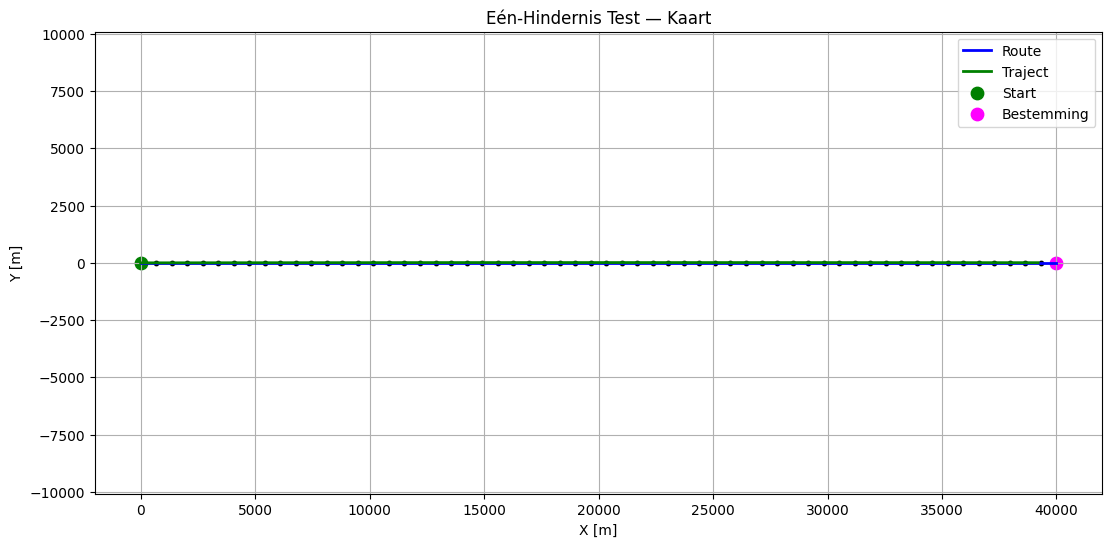

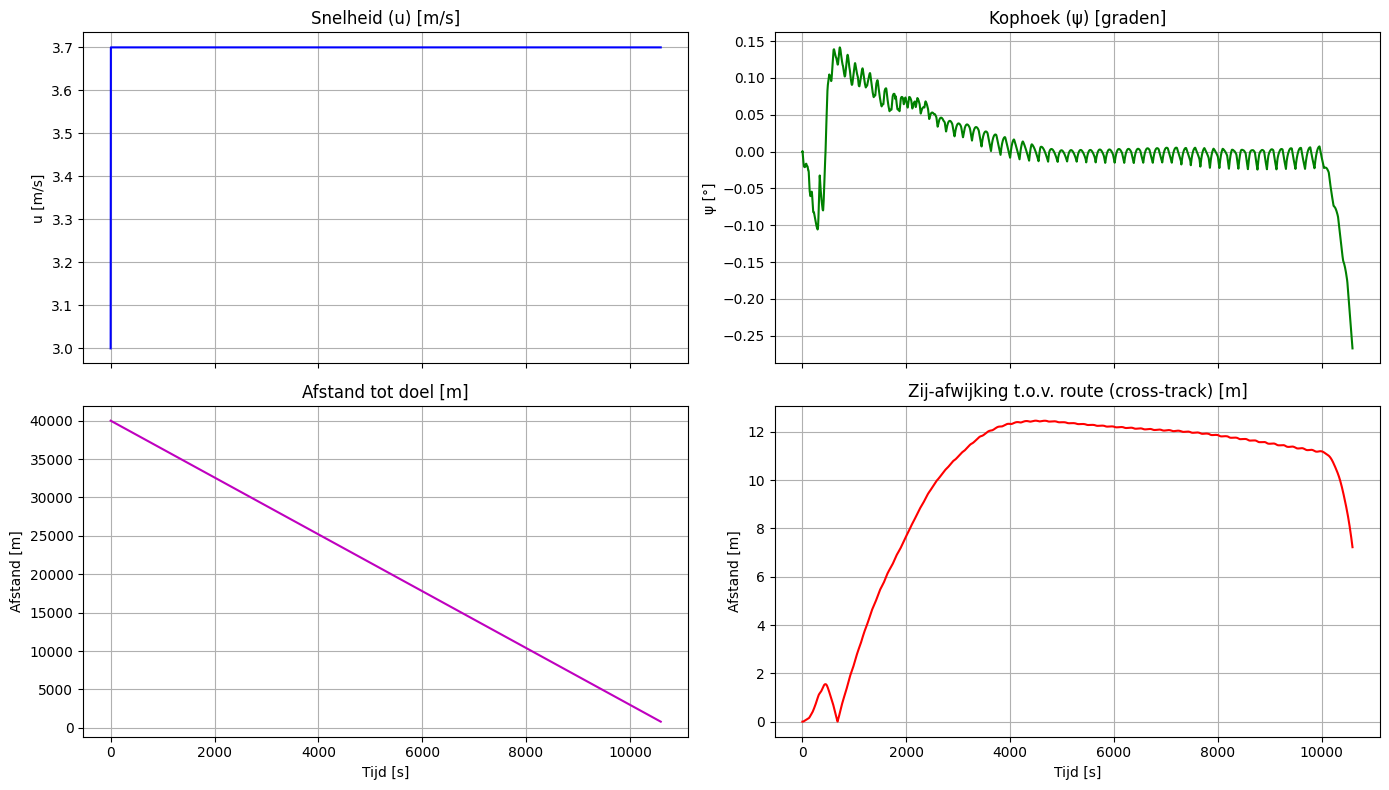

In [12]:
# ============================================================
# =============== CONFIG (edit this section) =================
# ============================================================

CONFIG = {
    "RUN_DIR": "./logs_ship_20260313_101353",  # <-- change to your run folder
    "STAGE": 4,

    "origin": (0.0, 0.0),
    "destination": (40000.0, 0.0),

    "obstacles": [],

    "dt": 5.0,          # seconds per step
    "max_steps": None,  # None => auto-compute from distance/speed; or set an int

    # Time / dynamics
    "dt": 2.0,              # seconds per step (bigger dt => fewer steps to finish)
    "max_steps": None,      # None => auto-compute; or set an int (e.g., 4000)

    # Assisted controller (policy + heading-hold blending)
    "assist": {
        "lookahead": 3,          # 2 → 3 helps smoother steering
        "kp_rudder": 1.2,        # 0.9 → 1.2
        "alpha_blend": 0.3,      # 0.5 → 0.3 (assist dominates)
        "throttle_floor": 0.35,  # slightly slower base speed
    },
    "env_tuning": {
        "rudder_gain": 0.035,    # 0.03 → 0.035 for more yaw authority
        "wp_switch_radius": 800, # 500 → 800
        "time_margin": 1.3,
    },

    # Diagnostics
    "diagnostic_steps": 0,  # print first N steps
}

# ==== Run it ====
run_single_obstacle_assisted(CONFIG)


--- Loading model and normalization statistics ---
Model: ./logs_ship_20260313_101353/stage_4/best/best_model.zip
VecNormalize: ./logs_ship_20260313_101353/stage_4/vecnormalize.pkl
Loaded normalization stats (not applying wrapper behavior).

Max steps set to: 7028

🚨 VecEnv done triggered! Info returned:
[{'TimeLimit.truncated': False, 'terminal_observation': array([ 3.9200176e+04,  6.2819743e+00, -3.5071007e-03,  3.7000000e+00,
        7.9982611e+02, -6.2819743e+00], dtype=float32), 'episode': {'r': np.float32(-1.1186716e+08), 'l': np.int32(5340), 't': 5.448468}}]

--- RESULT ---
ℹ Episode ended by VecEnv at step 5340.


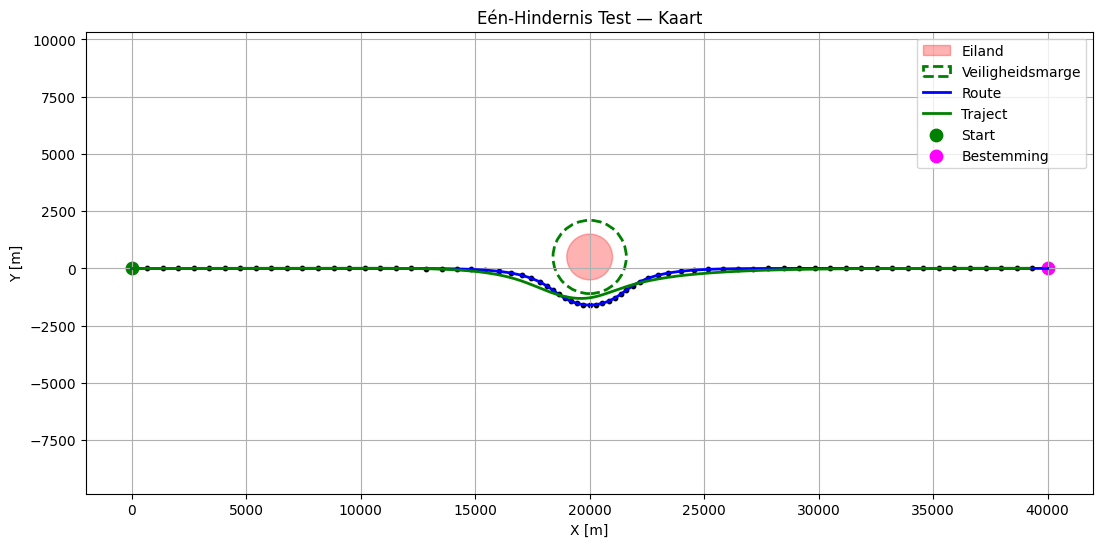

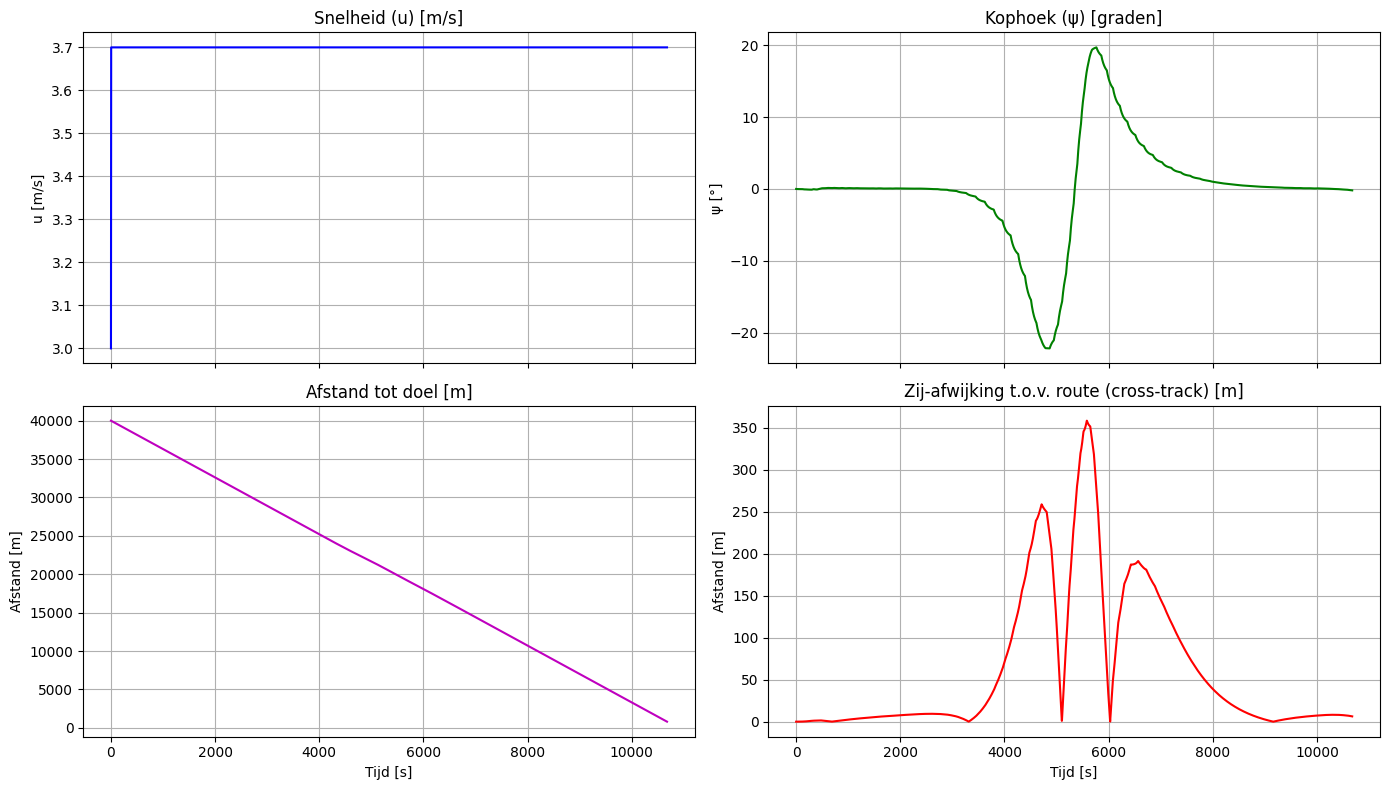

In [6]:
# ============================================================
# =============== CONFIG (edit this section) =================
# ============================================================

CONFIG = {
    "RUN_DIR": "./logs_ship_20260313_101353",  # <-- change to your run folder
    "STAGE": 4,

    "origin": (0.0, 0.0),
    "destination": (40000.0, 0.0),

    "obstacles": [
        {"type": "circle", "center": (20000.0, 500.0), "radius": 1000.0},
    ],

    # Time / dynamics
    "dt": 2.0,              # seconds per step (bigger dt => fewer steps to finish)
    "max_steps": None,      # None => auto-compute; or set an int (e.g., 4000)

    # Assisted controller (policy + heading-hold blending)
    "assist": {
        "lookahead": 3,          # 2 → 3 helps smoother steering
        "kp_rudder": 1.2,        # 0.9 → 1.2
        "alpha_blend": 0.3,      # 0.5 → 0.3 (assist dominates)
        "throttle_floor": 0.35,  # slightly slower base speed
    },
    "env_tuning": {
        "rudder_gain": 0.035,    # 0.03 → 0.035 for more yaw authority
        "wp_switch_radius": 800, # 500 → 800
        "time_margin": 1.3,
    },

    # Diagnostics
    "diagnostic_steps": 0,  # print first N steps
}

# ==== Run it ====
run_single_obstacle_assisted(CONFIG)

## Run a test - a route from destination to origin with two obstacles


--- Loading model and normalization statistics ---
Model: ./logs_ship_20260313_101353/stage_4/best/best_model.zip
VecNormalize: ./logs_ship_20260313_101353/stage_4/vecnormalize.pkl
Loaded normalization stats (not applying wrapper behavior).

Max steps set to: 7036

🚨 VecEnv done triggered! Info returned:
[{'TimeLimit.truncated': False, 'terminal_observation': array([3.9201824e+04, 1.9658464e+03, 4.7055699e-02, 3.7000000e+00,
       7.9817645e+02, 3.4153606e+01], dtype=float32), 'episode': {'r': np.float32(-1.1290096e+08), 'l': np.int32(5379), 't': 5.200802}}]

--- RESULT ---
ℹ Episode ended by VecEnv at step 5379.


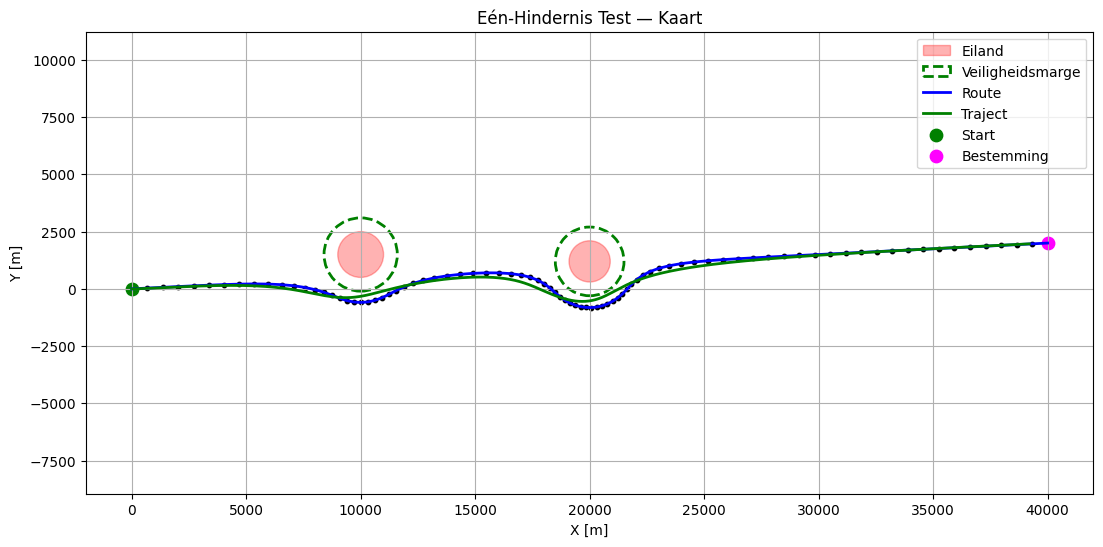

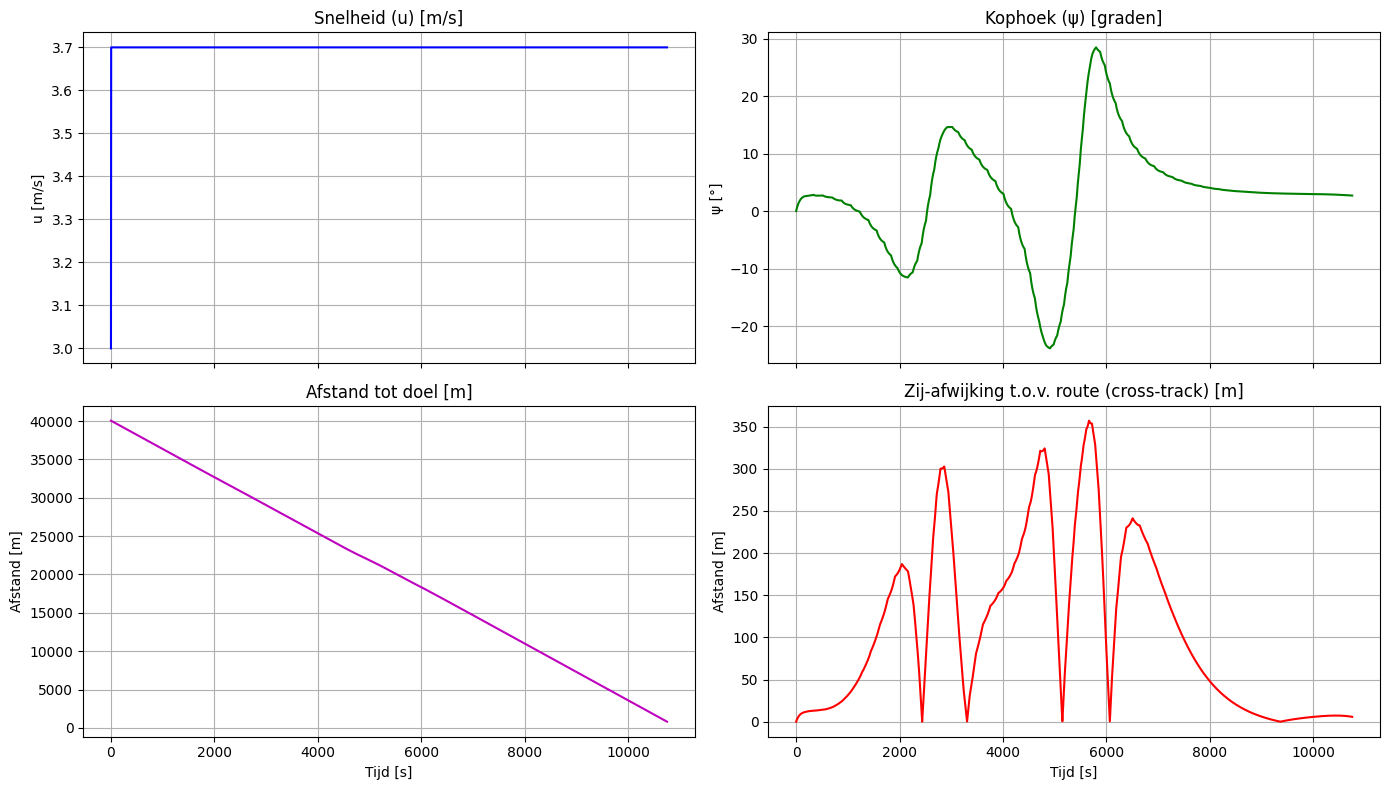

In [7]:
CONFIG = {
    # Paths
    "RUN_DIR": "./logs_ship_20260313_101353",  # <-- change to your run folder
    "STAGE": 4,

    # Scenario (geometry)
    "origin": (0.0, 0.0),
    "destination": (40000.0, 2000.0),

    # Obstacles: list of circles. Use one obstacle or add more.
    "obstacles": [
        {"type": "circle", "center": (10000.0, 1500.0), "radius": 1000.0},  # single mid-course island
        # Add more if you wish:
        {"type": "circle", "center": (20000.0, 1200.0), "radius": 900.0},
    ],

    # Time / dynamics
    "dt": 2.0,              # seconds per step (bigger dt => fewer steps to finish)
    "max_steps": None,      # None => auto-compute; or set an int (e.g., 4000)

    # Assisted controller (policy + heading-hold blending)
    "assist": {
        "lookahead": 3,          # 2 → 3 helps smoother steering
        "kp_rudder": 1.2,        # 0.9 → 1.2
        "alpha_blend": 0.3,      # 0.5 → 0.3 (assist dominates)
        "throttle_floor": 0.35,  # slightly slower base speed
    },
    "env_tuning": {
        "rudder_gain": 0.035,    # 0.03 → 0.035 for more yaw authority
        "wp_switch_radius": 800, # 500 → 800
        "time_margin": 1.3,
    },

    # Diagnostics
    "diagnostic_steps": 0,  # print first N steps
}

# ==== Run it ====
run_single_obstacle_assisted(CONFIG)

## Run a test - two vessel encountering

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Helpers
# =========================
def wrap_pi(a):
    return np.arctan2(np.sin(a), np.cos(a))

def unit_tangent_and_normal(origin, destination):
    o = np.asarray(origin, float)
    d = np.asarray(destination, float)
    v = d - o
    L = np.linalg.norm(v)
    if L < 1e-9:
        t_hat = np.array([1.0, 0.0])
    else:
        t_hat = v / L
    n_hat = np.array([-t_hat[1], t_hat[0]])  # left normal (+90°)
    r_hat = np.array([ t_hat[1],-t_hat[0]])  # right normal (-90°) for starboard bias
    return t_hat, n_hat, r_hat

def auto_steps(origin, destination, dt, throttle_floor, margin):
    L = float(np.linalg.norm(np.asarray(destination, float) - np.asarray(origin, float)))
    v_expect = 3.0 + 2.0 * float(throttle_floor)
    return int(np.ceil((L / (v_expect * dt)) * margin))

def vf_los_command(pos, psi, o, d, vf_gain, kp_h, kd_h, prev_epsi):
    """Vector-field LOS command for straight line o->d."""
    t_hat, n_hat, _ = unit_tangent_and_normal(o, d)
    # signed cross-track error: (p - o) · n_hat
    e = float(np.dot(np.asarray(pos, float) - np.asarray(o, float), n_hat))
    # desired direction: t_hat - k * e * n_hat
    v_d = t_hat - vf_gain * e * n_hat
    if np.linalg.norm(v_d) < 1e-12:
        v_d = t_hat.copy()
    chi_d = float(np.arctan2(v_d[1], v_d[0]))
    epsi = wrap_pi(chi_d - psi)
    deps = wrap_pi(epsi - prev_epsi)
    rudder = np.clip(kp_h * epsi + kd_h * deps, -1.0, 1.0)
    return rudder, epsi

def dynamic_avoidance_vec(my_pos, my_t_hat, other_pos, avoid_start, avoid_clear, avoid_gain, colregs_bias):
    """
    Repulsive vector away from 'other_pos' if within avoid_start.
    Adds a small starboard bias when the other is ahead (closing).
    Returns a vector to add to desired velocity direction before heading control.
    """
    p = np.asarray(my_pos, float)
    q = np.asarray(other_pos, float)
    rel = p - q
    d = np.linalg.norm(rel)
    if d < 1e-6:
        # overlap; push along current starboard direction strongly
        r_hat = np.array([ my_t_hat[1], -my_t_hat[0] ])
        return (avoid_gain + 1.0) * r_hat

    if d >= avoid_start:
        return np.zeros(2)

    u_rel = rel / d
    # shape function: stronger as d -> avoid_clear, zero at d >= avoid_start
    # linear taper between avoid_clear and avoid_start
    effective_start = max(avoid_start, avoid_clear + 1.0)
    w = np.clip((effective_start - d) / (effective_start - avoid_clear), 0.0, 1.0)
    repulse = avoid_gain * w * u_rel  # away from other

    # Starboard bias if the other is generally ahead along my tangent
    ahead = np.dot((q - p), my_t_hat) > 0.0
    closing = np.dot(u_rel, my_t_hat) < 0.0  # other towards me
    if ahead and closing and colregs_bias > 1e-6:
        r_hat = np.array([ my_t_hat[1], -my_t_hat[0] ])  # starboard side (right)
        repulse += colregs_bias * r_hat

    return repulse

def straight_route(o, d, n_pts=60):
    o = np.asarray(o, float); d = np.asarray(d, float)
    return [ (o*(1-t) + d*t).astype(float) for t in np.linspace(0,1,n_pts) ]


# =========================
# Two-vessel runner
# =========================
def run_two_vessels_same_route(cfg):
    # Build two ShipEnv raw envs (no PPO here)
    envA = ShipEnv(curriculum_stage=4, plan_route_once=True, clearance=600.0, dt=float(cfg["dt"]))
    envB = ShipEnv(curriculum_stage=4, plan_route_once=True, clearance=600.0, dt=float(cfg["dt"]))

    # Geometry
    O = np.array(cfg["origin"], dtype=np.float32)
    D = np.array(cfg["destination"], dtype=np.float32)

    # Vessel A: O -> D
    envA.origin = O.copy(); envA.destination = D.copy()
    envA._rudder_gain = float(cfg["rudder_gain"]); envA._wp_switch_radius = float(cfg["wp_switch_radius"])
    envA.route = straight_route(envA.origin, envA.destination, 60); envA._route_cache = envA.route
    envA._offset_cache = {"circles":[], "polygons":[]}

    # Vessel B: D -> O
    envB.origin = D.copy(); envB.destination = O.copy()
    envB._rudder_gain = float(cfg["rudder_gain"]); envB._wp_switch_radius = float(cfg["wp_switch_radius"])
    envB.route = straight_route(envB.origin, envB.destination, 60); envB._route_cache = envB.route
    envB._offset_cache = {"circles":[], "polygons":[]}

    # Time budget
    if cfg["max_steps"] is not None:
        steps_budget = int(cfg["max_steps"])
    else:
        stepsA = auto_steps(envA.origin, envA.destination, envA.dt, cfg["throttle_floor"], cfg["time_margin"])
        stepsB = auto_steps(envB.origin, envB.destination, envB.dt, cfg["throttle_floor"], cfg["time_margin"])
        steps_budget = max(envA._max_steps, envB._max_steps, stepsA, stepsB)
    envA._max_steps = steps_budget; envB._max_steps = steps_budget
    print(f"Max steps per vessel: {steps_budget}")

    # Reset
    obsA, _ = envA.reset(seed=42)
    obsB, _ = envB.reset(seed=43)

    # Precompute tangents/normals for each track
    tA, nA, rA = unit_tangent_and_normal(envA.origin, envA.destination)
    tB, nB, rB = unit_tangent_and_normal(envB.origin, envB.destination)

    # Gains
    vf_gain   = float(cfg["vf_gain"])
    kp_h      = float(cfg["kp_heading"])
    kd_h      = float(cfg["kd_heading"])
    thr_floor = float(cfg["throttle_floor"])

    avoid_start = float(cfg["avoid_start"])
    avoid_clear = float(cfg["avoid_clearance"])
    avoid_gain  = float(cfg["avoid_gain"])
    colregs_bias= float(cfg["colregs_bias"])
    diagN       = int(cfg["diagnostic_steps"])
    coll_rad    = float(cfg["collision_radius"])

    # Telemetry
    xsA, ysA, usA, psisA = [], [], [], []
    xsB, ysB, usB, psisB = [], [], [], []
    sep_series = []

    prev_epsi_A = 0.0
    prev_epsi_B = 0.0

    termA = None; termB = None
    steps = 0

    print(f"\n--- Diagnostic (first {diagN} steps) ---")
    for t in range(steps_budget):
        steps = t + 1

        # States
        pA = np.array([float(envA.x), float(envA.y)], float)
        pB = np.array([float(envB.x), float(envB.y)], float)
        psiA, psiB = float(envA.psi), float(envB.psi)

        # Telemetry
        xsA.append(pA[0]); ysA.append(pA[1]); usA.append(float(envA.u)); psisA.append(psiA)
        xsB.append(pB[0]); ysB.append(pB[1]); usB.append(float(envB.u)); psisB.append(psiB)

        # VF-LOS base rudders
        rudA_base, epsiA = vf_los_command(pA, psiA, envA.origin, envA.destination, vf_gain, kp_h, kd_h, prev_epsi_A)
        prev_epsi_A = epsiA
        rudB_base, epsiB = vf_los_command(pB, psiB, envB.origin, envB.destination, vf_gain, kp_h, kd_h, prev_epsi_B)
        prev_epsi_B = epsiB

        # Dynamic avoidance vectors (treat other as moving circular obstacle)
        vA_avoid = dynamic_avoidance_vec(pA, tA, pB, avoid_start, avoid_clear, avoid_gain, colregs_bias)
        vB_avoid = dynamic_avoidance_vec(pB, tB, pA, avoid_start, avoid_clear, avoid_gain, colregs_bias)

        # Adjust desired direction by adding avoidance vector *before* computing rudder
        # Project new desired direction into a heading error again:
        def rudder_from_vector(psi, base_o, base_d, avoid_vec):
            t_hat, n_hat, _ = unit_tangent_and_normal(base_o, base_d)
            e = float(np.dot((np.array([envA.x, envA.y]) - np.asarray(base_o, float)), n_hat))  # not used; keep simple
            v_d = t_hat + avoid_vec
            if np.linalg.norm(v_d) < 1e-6: v_d = t_hat.copy()
            chi_d = float(np.arctan2(v_d[1], v_d[0]))
            epsi = wrap_pi(chi_d - psi)
            # Use P only here (D already in base), small gain
            return np.clip(0.8 * epsi, -1.0, 1.0)

        rudA_avoid = rudder_from_vector(psiA, envA.origin, envA.destination, vA_avoid)
        rudB_avoid = rudder_from_vector(psiB, envB.origin, envB.destination, vB_avoid)

        # Combine base VF rudder with avoidance rudder
        rudA = np.clip(rudA_base + rudA_avoid, -1.0, 1.0)
        rudB = np.clip(rudB_base + rudB_avoid, -1.0, 1.0)

        # Throttle floors
        thrA = thr_floor
        thrB = thr_floor

        # Step both envs (raw Gymnasium API)
        _, _, termA_now, truncA, _ = envA.step(np.array([rudA, thrA], dtype=np.float32))
        _, _, termB_now, truncB, _ = envB.step(np.array([rudB, thrB], dtype=np.float32))

        # Diagnostics
        if t < diagN:
            distA = float(np.linalg.norm(np.asarray(envA.destination, float) - pA))
            distB = float(np.linalg.norm(np.asarray(envB.destination, float) - pB))
            sep   = float(np.linalg.norm(pA - pB))
            print(f"t={t:02d} | A: d_goal={distA:7.1f} eψ={np.degrees(epsiA):6.1f}° "
                  f"| B: d_goal={distB:7.1f} eψ={np.degrees(epsiB):6.1f}°  || sep={sep:7.1f} m")

        # Separation tracking
        sep = float(np.linalg.norm(pA - pB))
        sep_series.append(sep)

        # Goal checks (within 200 m)
        if termA is None and float(np.linalg.norm(np.asarray(envA.destination, float) - pA)) < 200.0:
            termA = "reached_goal"
        if termB is None and float(np.linalg.norm(np.asarray(envB.destination, float) - pB)) < 200.0:
            termB = "reached_goal"

        # Collision check
        if sep < coll_rad:
            termA = termA or "collision"
            termB = termB or "collision"
            break

        # Env done
        if termA is None and (bool(termA_now) or bool(truncA)):
            termA = "env_done"
        if termB is None and (bool(termB_now) or bool(truncB)):
            termB = "env_done"

        # Both finished?
        if termA in ("reached_goal", "env_done") and termB in ("reached_goal", "env_done"):
            break

    # Report
    min_sep = float(np.min(sep_series)) if sep_series else float("nan")
    print("\n--- Summary ---")
    print(f"Steps run: {steps}")
    print(f"Min separation: {min_sep:.1f} m  (collision radius = {coll_rad:.1f} m)")
    print(f"Vessel A termination: {termA}")
    print(f"Vessel B termination: {termB}")

    # Plots
    trajA = np.column_stack([xsA, ysA])
    trajB = np.column_stack([xsB, ysB])

    plt.figure(figsize=(13,6))
    ax = plt.gca()
    # Both vessels use the same straight route (no offset)
    R_center = np.asarray(straight_route(CFG["origin"], CFG["destination"], 60))
    plt.plot(R_center[:,0], R_center[:,1], 'k--', linewidth=1.5, label="Centerline Route (shared)")

    plt.plot(trajA[:,0], trajA[:,1], 'g-', linewidth=2, label="Trajectory A (O→D)")
    plt.plot(trajB[:,0], trajB[:,1], 'r-', linewidth=2, label="Trajectory B (D→O)")

    plt.scatter([CFG["origin"][0]],[CFG["origin"][1]], c='green', s=80, label="Origin")
    plt.scatter([CFG["destination"][0]],[CFG["destination"][1]], c='magenta', s=80, label="Destination")
    plt.xlabel("X [m]"); plt.ylabel("Y [m]")
    plt.title("Two Vessels — Same Route, Dynamic Mutual Avoidance")
    plt.axis("equal"); plt.grid(True); plt.legend(loc="best")
    plt.show()

    # Separation vs time
    t_axis = np.arange(len(sep_series)) * float(envA.dt)
    plt.figure(figsize=(10,3))
    plt.plot(t_axis, sep_series, 'k-')
    plt.axhline(coll_rad, color='r', linestyle='--', label="Collision radius")
    plt.title("Inter‑Vessel Separation vs Time")
    plt.xlabel("Time [s]"); plt.ylabel("Separation [m]")
    plt.grid(True); plt.legend(); plt.show()


Max steps per vessel: 3000

--- Diagnostic (first 5 steps) ---
t=00 | A: d_goal=40000.0 eψ=   0.0° | B: d_goal=40000.0 eψ= 180.0°  || sep=40000.0 m
t=01 | A: d_goal=39980.0 eψ=   0.0° | B: d_goal=40020.0 eψ= 177.7°  || sep=40000.0 m
t=02 | A: d_goal=39960.0 eψ=   0.0° | B: d_goal=40039.9 eψ= 175.5°  || sep=39999.9 m
t=03 | A: d_goal=39940.0 eψ=   0.0° | B: d_goal=40059.8 eψ= 173.3°  || sep=39999.8 m
t=04 | A: d_goal=39920.0 eψ=   0.0° | B: d_goal=40079.5 eψ= 171.2°  || sep=39999.5 m

--- Summary ---
Steps run: 2078
Min separation: 579.6 m  (collision radius = 250.0 m)
Vessel A termination: env_done
Vessel B termination: env_done


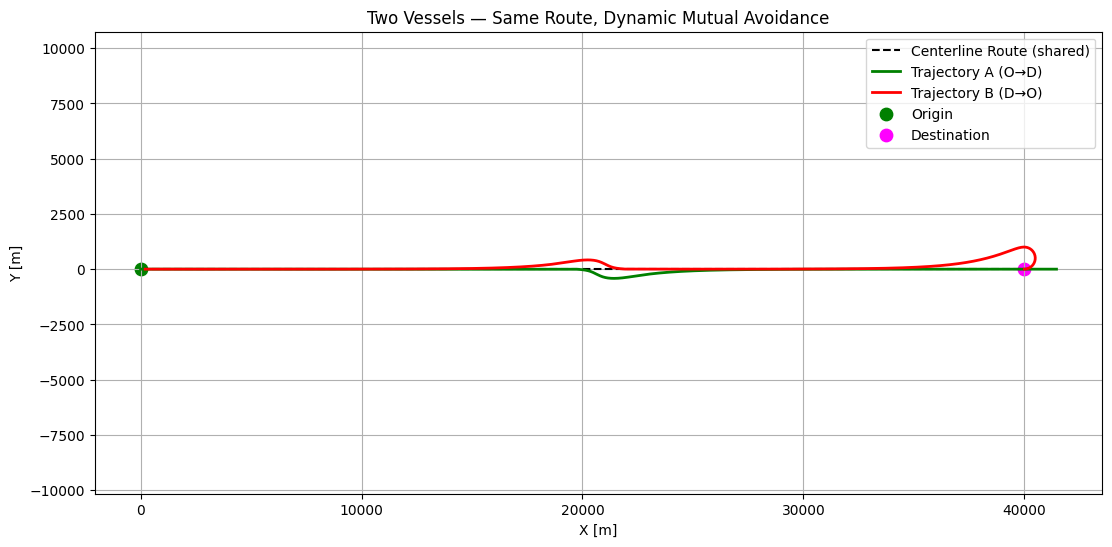

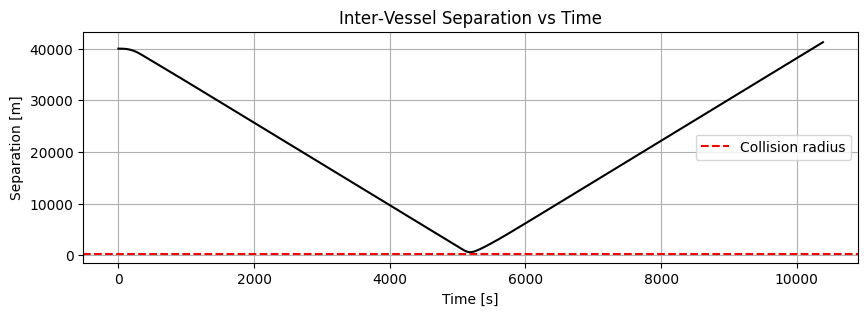

In [9]:
# =========================
# CONFIG — edit here
# =========================
CFG = {
    "origin":      (0.0, 0.0),
    "destination": (40000.0, 0.0),

    # Time & steps
    "dt": 5.0,           # seconds per step
    "max_steps": None,   # None => auto-compute from distance & speed

    # Ship env tuning (both vessels)
    "rudder_gain": 0.04,      # psi += rudder_gain * rudder (stronger = more responsive)
    "wp_switch_radius": 500.0,# for completeness; not needed by LOS but harmless

    # VF-LOS (line following) gains
    "vf_gain": 0.0008,   # pull toward centerline (1/m)
    "kp_heading": 1.2,   # heading P gain
    "kd_heading": 0.3,   # heading D gain (damping)

    # Speed policy
    "throttle_floor": 0.5,  # u ≈ 3 + 2*thr = 4.0 m/s

    # Dynamic mutual avoidance (moving circular obstacles)
    "avoid_start": 2500.0,     # start repulsion within this range [m]
    "avoid_clearance": 600.0,  # safety margin [m] (like clearance in training)
    "avoid_gain": 1.2,         # strength of repulsion (0.8 .. 1.5 reasonable)
    "collision_radius": 250.0, # considered collision if closer than this [m]

    # Starboard bias for head-on meeting
    "colregs_bias": 0.25,      # 0..0.5 lateral bias to starboard when head-on

    # Diagnostics
    "diagnostic_steps": 5,
    "time_margin": 1.3         # slack for auto time budget
}

# ==== RUN ====
run_two_vessels_same_route(CFG)

## An example - just generating the route

In [10]:
# # ============================================================
# # PLOTTING
# # ============================================================

def plot_route(origin, destination, obstacles, offset_data, route):
    plt.figure(figsize=(12, 6))

    # Track legend entries to avoid duplicates
    added = set()

    ax = plt.gca()

    # -------------------------------------------------------
    # 1) DRAW OBSTACLES
    # -------------------------------------------------------
    for obs in obstacles:
        if obs["type"] == "circle":
            cx, cy = obs["center"]
            r = obs["radius"]
            circ = plt.Circle((cx, cy), r, color='red', alpha=0.35)
            ax.add_patch(circ)
            if "Island (circle)" not in added:
                circ.set_label("Island (circle)")
                added.add("Island (circle)")

        elif obs["type"] == "polygon":
            poly = np.array(obs["points"])
            poly = ensure_ccw(poly)
            plt.fill(poly[:,0], poly[:,1], color='red', alpha=0.35)
            if "Island (polygon)" not in added:
                plt.plot([], [], color='red', alpha=0.35, label="Island (polygon)")
                added.add("Island (polygon)")

    # -------------------------------------------------------
    # 2) DRAW CLEARANCE GEOMETRY (from offset_data)
    # -------------------------------------------------------

    # Circles
    for (c, Rc) in offset_data["circles"]:
        cc = plt.Circle((c[0], c[1]), Rc, fill=False,
                        color='green', linestyle='--', linewidth=2)
        ax.add_patch(cc)
        if "Clearance (circle)" not in added:
            cc.set_label("Clearance (circle)")
            added.add("Clearance (circle)")

    # Polygons
    for off_poly in offset_data["polygons"]:
        off = np.array(off_poly)
        plt.plot(np.r_[off[:,0], off[0,0]],
                 np.r_[off[:,1], off[0,1]],
                 'g--', linewidth=2)
        if "Clearance (polygon)" not in added:
            plt.plot([], [], 'g--', linewidth=2, label="Clearance (polygon)")
            added.add("Clearance (polygon)")

    # -------------------------------------------------------
    # 3) DRAW ROUTE
    # -------------------------------------------------------
    R = np.array(route)
    plt.plot(R[:,0], R[:,1], 'b-', linewidth=2, label="Route")
    plt.scatter(R[:,0], R[:,1], s=10, c='black')

    # Endpoints
    plt.plot(origin[0], origin[1], 'go', markersize=12, label="Origin")
    plt.plot(destination[0], destination[1], 'mo', markersize=12, label="Destination")

    # -------------------------------------------------------
    # Final formatting
    # -------------------------------------------------------
    plt.legend(loc="best")
    plt.grid(True)
    plt.axis("equal")
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Obstacles + Clearance + Route")
    plt.show()

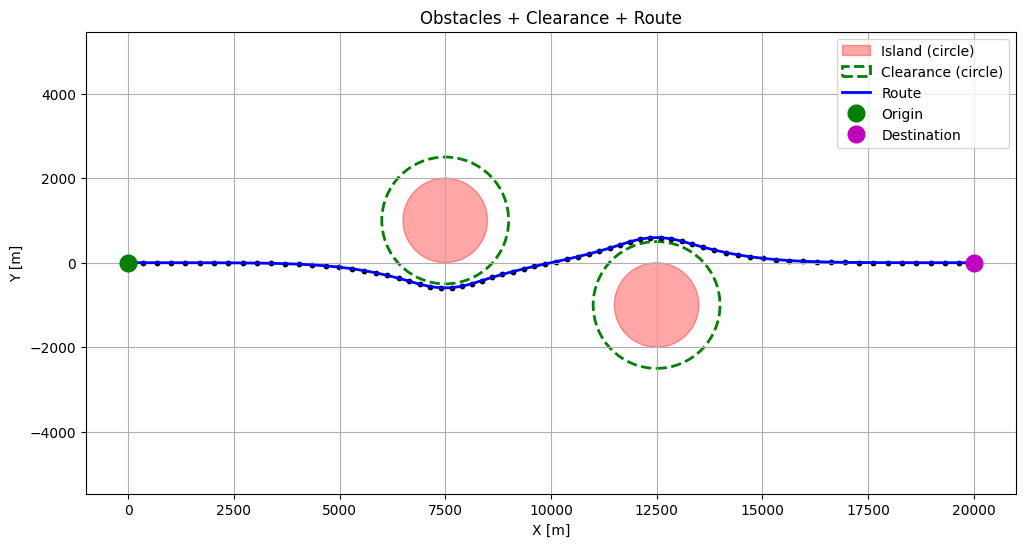

In [11]:
origin = (0, 0)
destination = (20000, 0)

obstacles = [
    { "type": "circle", "center": (7500, 1000),   "radius": 1000 },
    { "type": "circle", "center": (12500, -1000), "radius": 1000 },
]

clearance = 500

route, offset_data = optimize_route(
    origin,destination,obstacles,clearance,
    n_initial=60,repel_gain=0.4,smooth_gain=0.25,iterations=100
)

plot_route(origin,destination,obstacles,offset_data,route)
